<div style='text-align:center'>
<h1 style='color:#1a3c5e;'>Projet: Modèle de Scoring Crédit</h1>
<h2 style='color:#2e6b9e;'>Prédiction du Risque de Défaut</h2>
<hr style='width:60%; margin:20px auto;'>
<h3>Data Science &amp; Machine Learning | Contexte Bancaire</h3>
<p style='font-size:1.2em;'><strong>Auteur :</strong> AKOTA Yao Jérôme</p>


</div>

## 1. Contexte et Objectifs du Projet

### 1.1 Contexte

La **Banque Ouest Africaine de Développement (BOAD)** est une institution financière sous‑régionale qui finance des projets de développement dans les **8 pays de l'UEMOA** (Union Économique et Monétaire Ouest Africaine) : Bénin, Burkina Faso, Côte d'Ivoire, Guinée‑Bissau, Mali, Niger, Sénégal et Togo.

Dans ce contexte, l'évaluation du **risque de crédit** est une fonction fondamentale. Le **scoring crédit** désigne l'ensemble des techniques statistiques et algorithmiques permettant d'attribuer une **note de risque** à chaque emprunteur, afin de prédire sa probabilité de **défaut** (c'est‑à‑dire l'incapacité à rembourser son prêt).

### 1.2 Problématique

Pour une banque de développement, un mauvais crédit se traduit par :
- **Pertes financières** directes sur les montants non remboursés
- **Ressources détournées** de projets de développement essentiels
- **Risque systémique** si les défaillances sont trop nombreuses

La question centrale est donc :

> *Comment prédire, au moment de la demande de prêt, si un emprunteur présente un risque élevé de défaut ?*

Il s'agit d'un problème de **classification binaire** : 'défaut = 1' (l'emprunteur fera défaut) vs 'défaut = 0' (bon remboursement).

### 1.3 Objectifs

Ce projet vise à :

1. **Construire un jeu de données réaliste** simulant des demandes de prêt dans la zone UEMOA
2. **Explorer et analyser** les facteurs de risque (analyse exploratoire)
3. **Entraîner et comparer** deux modèles de classification :
   - Régression Logistique (modèle interprétable)
   - Random Forest (modèle basé sur les arbres)
4. **Évaluer les performances** à l'aide de métriques adaptées (accuracy, précision, rappel, F1, AUC‑ROC)
5. **Formuler des recommandations** pour la gestion du risque de crédit à la BOAD

## 2. Importation des Bibliothèques

Avant de commencer, nous importons toutes les bibliothèques Python nécessaires. Chaque import est accompagné d'un commentaire expliquant son rôle dans le projet.

In [2]:

# Importation des bibliothèques nécessaires au projet

# warnings permet de masquer les avertissement de type Futurewarning ou autre
import warnings


import pandas as pd


import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

#  Modules de scikit-learn pour la modélisation 

# train_test_split : découpe le jeu de données en ensemble d'entraînement et de test
from sklearn.model_selection import train_test_split

# StandardScaler : met les variables numériques à la même échelle (moyenne=0, écart-type=1)
from sklearn.preprocessing import StandardScaler

# LogisticRegression : modèle de classification linéaire (régression logistique)
from sklearn.linear_model import LogisticRegression

# RandomForestClassifier : modèle d'ensemble basé sur des arbres de décision
from sklearn.ensemble import RandomForestClassifier

# accuracy_score : proportion de prédictions correctes
from sklearn.metrics import accuracy_score

# precision_score : proportion de vrais positifs parmi les positifs prédits
from sklearn.metrics import precision_score

# recall_score : proportion de vrais positifs parmi les positifs réels
from sklearn.metrics import recall_score

# f1_score : moyenne harmonique de la précision et du rappel
from sklearn.metrics import f1_score

# classification_report : rapport synthétique des métriques de classification
from sklearn.metrics import classification_report

# confusion_matrix : matrice croisant prédictions et valeurs réelles
from sklearn.metrics import confusion_matrix

# roc_curve : calcule les taux de faux/vrais positifs pour la courbe ROC
from sklearn.metrics import roc_curve

# auc : calcule l'aire sous la courbe ROC (AUC)
from sklearn.metrics import auc

# Configuration des graphiques 

# Définir la police DejaVu Sans pour un rendu propre des graphiques
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']

# Définir la taille par défaut des figures matplotlib
plt.rcParams['figure.figsize'] = (10, 6)

# Appliquer le style 'seaborn-v0_8-whitegrid' pour des graphiques propres
sns.set_style('whitegrid')

# Définir une palette de couleurs cohérente pour tous les graphiques seaborn
sns.set_palette('deep')

# Fixer la graine aléatoire pour garantir la reproductibilité des résultats
np.random.seed(42)



## 3. Création du Jeu de Données Synthétique

### 3.1 Pourquoi un jeu de données synthétique ?

Les données de crédit bancaire sont **confidentielles** et rarement publiques. Pour ce projet portfolio, nous créons un jeu de données **synthétique mais réaliste** qui simule 1 000 demandes de prêt dans la zone UEMOA. Les variables reflètent celles réellement utilisées dans les modèles de scoring crédit : revenus, montant du prêt, historique de crédit, etc.

### 3.2 Description des variables

<table style="width:100%; border-collapse: collapse; text-align: center; font-family: sans-serif;">
  <thead>
    <tr style="background-color: #f2f2f2; border-bottom: 2px solid #ddd;">
      <th>Variable</th>
      <th>Type</th>
      <th>Description</th>
    </tr>
  </thead>
  <tbody>
    <tr style="border-bottom: 1px solid #ddd;">
      <td>age</td>
      <td>Numérique</td>
      <td>Âge de l'emprunteur (22-65 ans)</td>
    </tr>
    <tr style="border-bottom: 1px solid #ddd;">
      <td>revenu_mensuel</td>
      <td>Numérique</td>
      <td>Revenu mensuel en FCFA (50 000 - 500 000)</td>
    </tr>
    <tr style="border-bottom: 1px solid #ddd;">
      <td>montant_pret</td>
      <td>Numérique</td>
      <td>Montant du prêt demandé en FCFA (500 000 - 50 000 000)</td>
    </tr>
    <tr style="border-bottom: 1px solid #ddd;">
      <td>duree_pret_mois</td>
      <td>Numérique</td>
      <td>Durée de remboursement en mois (6-120)</td>
    </tr>
    <tr style="border-bottom: 1px solid #ddd;">
      <td>taux_interet</td>
      <td>Numérique</td>
      <td>Taux d'intérêt annuel en % (3-15)</td>
    </tr>
    <tr style="border-bottom: 1px solid #ddd;">
      <td>nb_emprunts_anterieurs</td>
      <td>Numérique</td>
      <td>Nombre d'emprunts antérieurs (0-5)</td>
    </tr>
    <tr style="border-bottom: 1px solid #ddd;">
      <td>ratio_endettement</td>
      <td>Numérique</td>
      <td>Ratio dette/revenu calculé automatiquement</td>
    </tr>
    <tr style="border-bottom: 1px solid #ddd;">
      <td>score_historique</td>
      <td>Numérique</td>
      <td>Score d'historique de crédit (300-850)</td>
    </tr>
    <tr style="border-bottom: 1px solid #ddd;">
      <td>situation_familiale</td>
      <td>Catégorielle</td>
      <td>Célibataire, Marié, Divorcé</td>
    </tr>
    <tr style="border-bottom: 1px solid #ddd;">
      <td>secteur_activite</td>
      <td>Catégorielle</td>
      <td>Agriculture, Commerce, Services, Industrie, BTP</td>
    </tr>
    <tr style="border-bottom: 1px solid #ddd;">
      <td>garantie</td>
      <td>Catégorielle</td>
      <td>Présence d'une garantie (Oui/Non)</td>
    </tr>
    <tr>
      <td>defaut</td>
      <td>Binaire (cible)</td>
      <td>1 = défaut, 0 = bon remboursement</td>
    </tr>
  </tbody>
</table>

### 3.3 Génération des données

In [3]:

# Création du jeu de données synthétique (1 000 demandes de prêt)


np.random.seed(42)

# Nombre total de demandes de prêt simulées
n = 1000

# Âge de l'emprunteur : distribution uniforme entre 22 et 65 ans
age = np.random.randint(22, 66, size=n)

# Revenu mensuel en FCFA : distribution uniforme entre 50 000 et 500 000
revenu_mensuel = np.random.randint(50000, 500001, size=n)

# Montant du prêt en FCFA : distribution uniforme entre 500 000 et 50 000 000
montant_pret = np.random.randint(500000, 50000001, size=n)

# Durée de remboursement en mois : distribution uniforme entre 6 et 120
duree_pret_mois = np.random.randint(6, 121, size=n)

# Taux d'intérêt annuel en % : distribution uniforme entre 3 et 15
taux_interet = np.round(np.random.uniform(3, 15, size=n), 2)

# Nombre d'emprunts antérieurs : distribution uniforme entre 0 et 5
nb_emprunts_anterieurs = np.random.randint(0, 6, size=n)

# Score d'historique de crédit (300-850) : distribution normale centrée à 575
score_historique = np.clip(np.random.normal(575, 100, size=n), 300, 850).astype(int)

# Variables calculées

# Ratio d'endettement = montant_pret / (revenu_mensuel × duree_pret_mois)
# Ce ratio mesure la part du revenu consacrée au remboursement du prêt
ratio_endettement = np.round(montant_pret / (revenu_mensuel * duree_pret_mois), 4)

# Variables catégorielles 

# Situation familiale : choix aléatoire parmi 3 catégories
situations = ['célibataire', 'marié', 'divorcé']
situation_familiale = np.random.choice(situations, size=n, p=[0.45, 0.45, 0.10])

# Secteur d'activité : choix aléatoire parmi 5 secteurs économiques
secteurs = ['agriculture', 'commerce', 'services', 'industrie', 'btp']
secteur_activite = np.random.choice(secteurs, size=n, p=[0.25, 0.30, 0.20, 0.15, 0.10])

# Présence d'une garantie : 60% de 'oui', 40% de 'non'
garantie = np.random.choice(['oui', 'non'], size=n, p=[0.60, 0.40])

#  Variable cible (défaut) 
# La variable cible est générée de manière semi-réaliste :
# - Un score historique bas augmente le risque de défaut
# - Un ratio d'endettement élevé augmente le risque de défaut
# - L'absence de garantie augmente le risque de défaut

# Calcul d'un score de risque (logit) à partir de facteurs de risque
logit = (
    -3.0                                          # intercept (taux de défaut de base)
    + 0.003 * (850 - score_historique)           # score historique bas -> risque élevé
    + 2.0 * np.log1p(ratio_endettement)            # ratio endettement élevé -> risque élevé
    - 0.8 * (garantie == 'oui').astype(int)      # garantie -> risque bas
    - 0.005 * (revenu_mensuel / 10000)            # revenu élevé -> risque bas
    + np.random.normal(0, 0.8, size=n)            # bruit aléatoire
)

# Convertir le logit en probabilité via la fonction sigmoïde
prob_defaut = 1 / (1 + np.exp(-logit))

# Seuiller la probabilité à 0.5 pour obtenir la classe binaire (0 ou 1)
defaut = (prob_defaut >= 0.5).astype(int)

# Ajuster aléatoirement pour obtenir un taux de défaut d'environ 25%
# (re-flipper certaines étiquettes si nécessaire)
taux_cible = 0.25
taux_actuel = defaut.mean()
# Si le taux actuel est trop éloigné de la cible, on ajuste en re-seuillant
if abs(taux_actuel - taux_cible) > 0.03:
    # Recalculer le seuil pour atteindre environ 25% de défaut
    seuil = np.quantile(prob_defaut, 1 - taux_cible)
    defaut = (prob_defaut >= seuil).astype(int)

#  Assemblage du DataFrame 

# Créer un dictionnaire contenant toutes les colonnes du jeu de données
data = {
    'age': age,
    'revenu_mensuel': revenu_mensuel,
    'montant_pret': montant_pret,
    'duree_pret_mois': duree_pret_mois,
    'taux_interet': taux_interet,
    'nb_emprunts_anterieurs': nb_emprunts_anterieurs,
    'ratio_endettement': ratio_endettement,
    'score_historique': score_historique,
    'situation_familiale': situation_familiale,
    'secteur_activite': secteur_activite,
    'garantie': garantie,
    'defaut': defaut,
}

# Construire le DataFrame pandas à partir du dictionnaire
df = pd.DataFrame(data)

# Afficher la forme du DataFrame (lignes × colonnes)
print(f"DataFrame créé : {df.shape[0]} lignes × {df.shape[1]} colonnes")

# Afficher le taux de défaut observé
print(f"Taux de défaut observé : {df['defaut'].mean():.1%}")

DataFrame créé : 1000 lignes × 12 colonnes
Taux de défaut observé : 25.0%


### 3.4 Sauvegarde et aperçu des données

In [3]:

# Sauvegarde du jeu de données en fichier CSV
# Définir le chemin du fichier CSV de sortie
csv_path = r'C:\Users\akota\Desktop\donnees_credit.csv'

# Sauvegarder le DataFrame en CSV (sans l'index)
df.to_csv(csv_path, index=False, encoding='utf-8')

# Confirmer la sauvegarde
print(f"Données sauvegardées dans : {csv_path}")

Données sauvegardées dans : C:\Users\akota\Desktop\donnees_credit.csv


In [4]:

df.head()

,age,revenu_mensuel,montant_pret,duree_pret_mois,taux_interet,nb_emprunts_anterieurs,ratio_endettement,score_historique,situation_familiale,secteur_activite,garantie,defaut
0,60,447234,23789643,111,13.11,0,0.4792,556,marié,agriculture,oui,0
1,50,61302,36958065,94,9.59,3,6.4137,525,marié,agriculture,oui,1
2,36,379650,22989029,82,5.63,1,0.7385,449,marié,agriculture,oui,0
3,64,91157,2440369,75,3.40,2,0.3569,577,marié,industrie,oui,0
4,29,104917,42181557,49,5.58,4,8.2050,368,marié,agriculture,non,1


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     1000 non-null   int32  
 1   revenu_mensuel          1000 non-null   int32  
 2   montant_pret            1000 non-null   int32  
 3   duree_pret_mois         1000 non-null   int32  
 4   taux_interet            1000 non-null   float64
 5   nb_emprunts_anterieurs  1000 non-null   int32  
 6   ratio_endettement       1000 non-null   float64
 7   score_historique        1000 non-null   int64  
 8   situation_familiale     1000 non-null   str    
 9   secteur_activite        1000 non-null   str    
 10  garantie                1000 non-null   str    
 11  defaut                  1000 non-null   int64  
dtypes: float64(2), int32(5), int64(2), str(3)
memory usage: 74.3 KB


In [6]:
# Statistiques descriptives des variables numériques 
df.describe().round(2)

,age,revenu_mensuel,montant_pret,duree_pret_mois,taux_interet,nb_emprunts_anterieurs,ratio_endettement,score_historique,defaut
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,43.52,276075.19,25823112.40,61.66,9.21,2.57,3.47,572.02,0.25
std,12.61,129951.03,14170898.27,32.41,3.42,1.69,5.82,99.70,0.43
min,22.00,50126.00,519675.00,6.00,3.01,0.00,0.01,300.00,0.00
25%,33.00,166899.50,13157189.75,34.75,6.34,1.00,0.78,504.75,0.00
50%,44.00,273973.50,25948158.50,60.00,9.36,3.00,1.62,568.00,0.00
75%,54.00,386230.75,37951052.00,90.00,12.15,4.00,3.96,639.00,0.25
max,65.00,499662.00,49902807.00,120.00,14.99,5.00,91.69,839.00,1.00


## 4. Analyse Exploratoire des Données (EDA)

L'analyse exploratoire vise à **comprendre la structure** des données et à **identifier les patterns** pertinents avant la modélisation. Nous étudions successivement : la distribution de la cible, les variables numériques, les relations bivariées et les corrélations.

### 4.1 Distribution de la Variable Cible

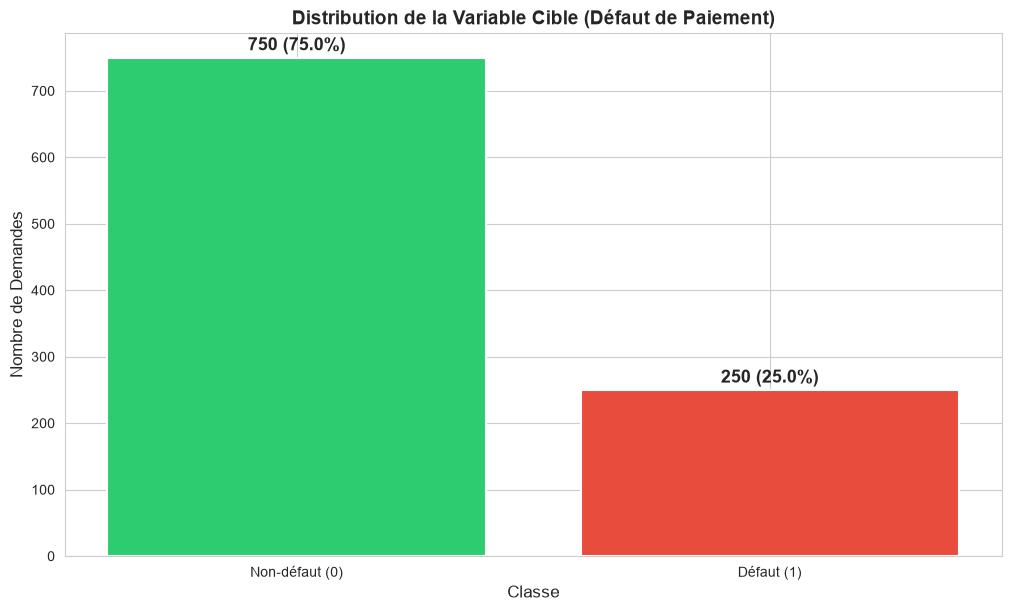

Non-défaut : 750 demandes (75.0%)
Défaut     : 250 demandes (25.0%)


In [7]:

# 4.1 Distribution de la variable cible 'defaut'
# Compter les occurrences de chaque classe (0 = bon, 1 = défaut)
comptes = df['defaut'].value_counts()  # comptes[0] = non-défaut, comptes[1] = défaut

# Calculer le pourcentage de chaque classe
pct_defaut = df['defaut'].value_counts(normalize=True) * 100

# Créer la figure avec un layout contraint pour éviter les chevauchements
fig, ax = plt.subplots(constrained_layout=True)

# Tracer un diagramme en barres 
couleurs = ['#2ecc71', '#e74c3c']  # vert = bon, rouge = défaut
barres = ax.bar(['Non-défaut (0)', 'Défaut (1)'], comptes.values,
                color=couleurs, edgecolor='white', linewidth=1.5)

# Ajouter le nombre et le pourcentage au‑dessus de chaque barre
for barre, nb, pct in zip(barres, comptes.values, pct_defaut.values):
    ax.text(barre.get_x() + barre.get_width()/2, barre.get_height() + 5,
            f'{nb} ({pct:.1f}%)', ha='center', va='bottom', fontsize=13, fontweight='bold')

# Titres et labels du graphique
ax.set_title('Distribution de la Variable Cible (Défaut de Paiement)', fontsize=14, fontweight='bold')
ax.set_ylabel('Nombre de Demandes', fontsize=12)
ax.set_xlabel('Classe', fontsize=12)



# Afficher le graphique
plt.show()

# Afficher un résumé textuel
print(f"Non-défaut : {comptes[0]} demandes ({pct_defaut[0]:.1f}%)")
print(f"Défaut     : {comptes[1]} demandes ({pct_defaut[1]:.1f}%)")

### Observations

- La distribution montre un **déséquilibre de classe** modéré : environ **75%** des emprunteurs ne font pas défaut et **25%** font défaut.
- Ce déséquilibre est réaliste pour un portefeuille bancaire.
- Il faudra en tenir compte lors de l'évaluation des modèles (le rappel du défaut sera particulièrement important).

### 4.2 Analyse Univariée des Variables Numériques

Nous examinons la distribution de chaque variable numérique à l'aide d'histogrammes avec estimation de la densité (KDE). Cela nous permet de détecter les valeurs aberrantes et la forme des distributions.

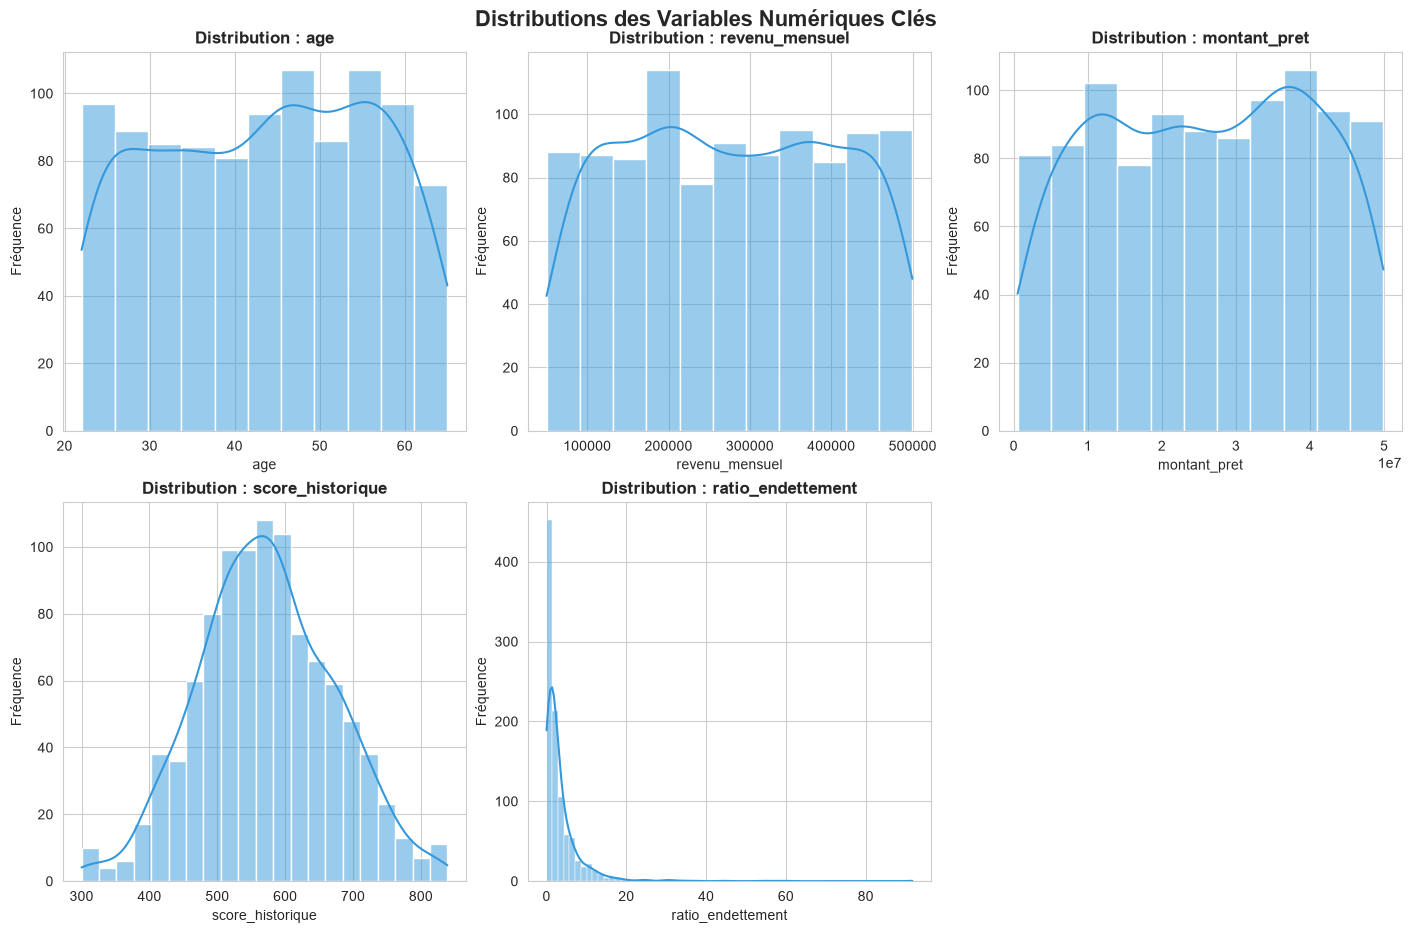

In [8]:

# 4.2 Histogrammes des variables numériques clés

# Liste des variables numériques à visualiser
variables_num = ['age', 'revenu_mensuel', 'montant_pret', 'score_historique', 'ratio_endettement']

# Créer une grille de sous-graphiques (2 lignes × 3 colonnes)
fig, axes = plt.subplots(2, 3, figsize=(14, 9), constrained_layout=True)

# Aplatir le tableau d'axes pour itérer facilement
axes = axes.flatten()

# Tracer un histogramme + KDE pour chaque variable
for i, var in enumerate(variables_num):
    # Histogramme avec courbe de densité (KDE)
    sns.histplot(df[var], kde=True, ax=axes[i], color='#3498db', edgecolor='white')
    # Titre de chaque sous-graphique
    axes[i].set_title(f'Distribution : {var}', fontsize=12, fontweight='bold')
    # Label de l'axe des ordonnées
    axes[i].set_ylabel('Fréquence', fontsize=10)

# Supprimer le 6e sous-graphique (vide, car on a 5 variables)
axes[-1].set_visible(False)

# Titre principal de la figure
fig.suptitle('Distributions des Variables Numériques Clés', fontsize=16, fontweight='bold', y=1.02)

# Sauvegarder la figure
#fig.savefig(, dpi=150)

# Afficher la figure
plt.show()

### Observations

- **Âge** : Distribution relativement uniforme entre 22 et 65 ans.
- **Revenu mensuel** : Distribution uniforme entre 50 000 et 500 000 FCFA.
- **Montant du prêt** : Répartition étalée sur toute la plage, avec des pics.
- **Score historique** : Distribution proche de la normale, centrée vers 575.
- **Ratio d'endettement** : Distribution **asymétrique à droite**  la plupart des emprunteurs ont un ratio modéré, mais certains présentent un endettement très élevé.

### 4.3 Analyse Bivariée : Variables par Rapport au Défaut

Nous comparons maintenant les distributions de chaque variable entre les deux groupes (défaut vs non‑défaut) pour identifier les facteurs discriminants.

#### 4.3.1 Boxplots des variables numériques par classe de défaut

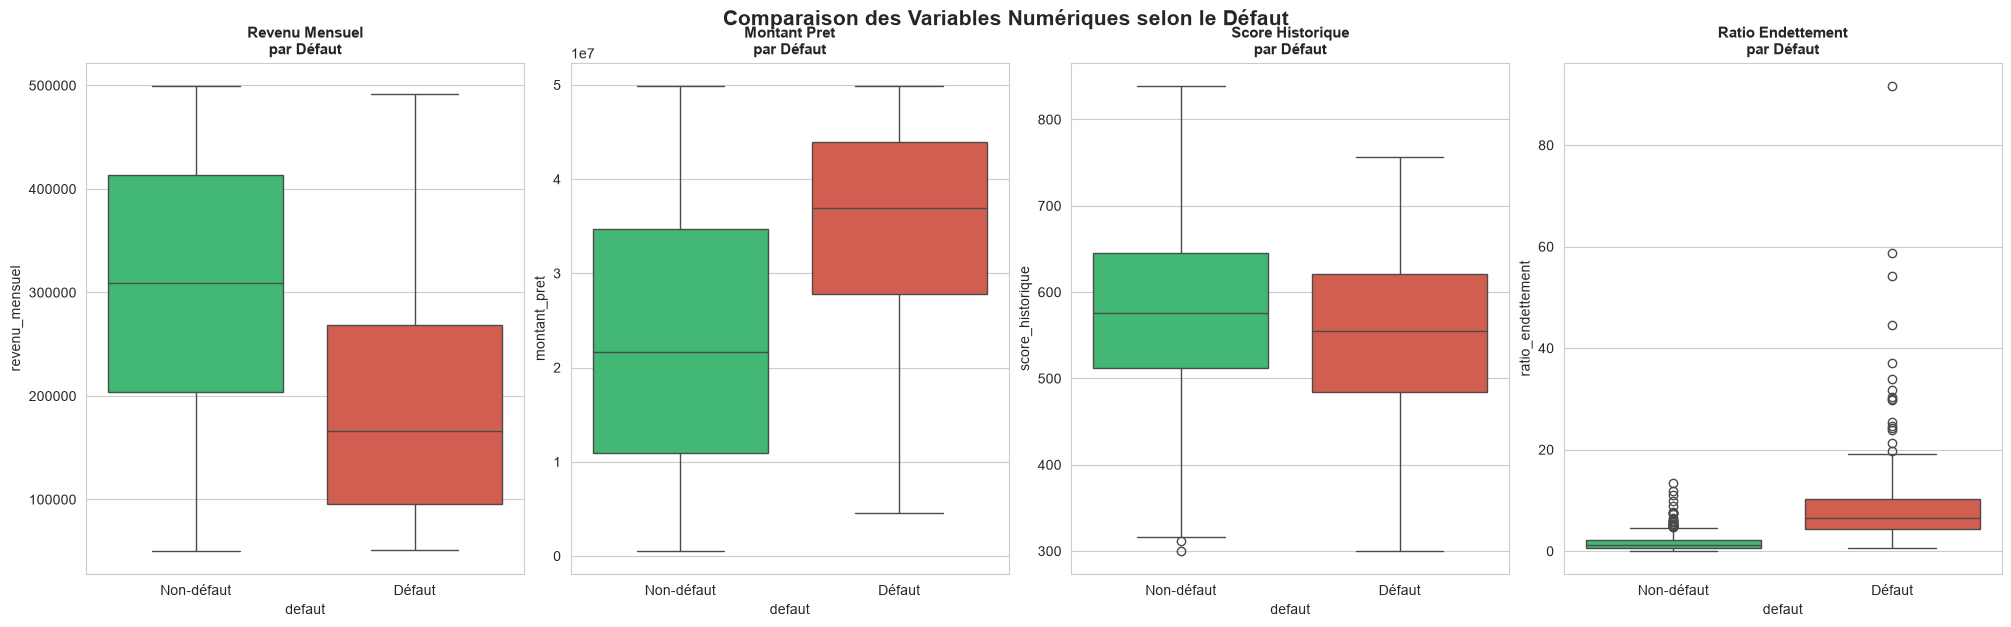

In [9]:

# 4.3.1  Boxplots : variables numériques selon le statut de défaut
# Variables pour les boxplots
vars_boxplot = ['revenu_mensuel', 'montant_pret', 'score_historique', 'ratio_endettement']

# Créer une grille de sous-graphiques (1 ligne × 4 colonnes)
fig, axes = plt.subplots(1, 4, figsize=(20, 6), constrained_layout=True)


# Tracer un boxplot pour chaque variable
for i, var in enumerate(vars_boxplot):
    # Boxplot comparant les distributions par classe de défaut
    sns.boxplot(x='defaut', y=var, data=df, ax=axes[i], hue='defaut', palette=['#2ecc71', '#e74c3c'], legend=False)
    # Personnaliser les labels de l'axe x (0/1 -> texte)
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Non-défaut', 'Défaut'])
    # Titre
    axes[i].set_title(f'{var.replace("_", " ").title()}\npar Défaut', fontsize=11, fontweight='bold')

# Titre principal
fig.suptitle('Comparaison des Variables Numériques selon le Défaut', fontsize=15, fontweight='bold', y=1.02)

# Sauvegarder la figure
fig.savefig(r'C:\Users\akota\Desktop\boxplots_defaut.png', dpi=150)

# Afficher
plt.show()

### Observations

- **Score historique** : Les emprunteurs en défaut ont tendance à avoir un score historique **plus bas**.
- **Ratio d'endettement** : Les défaillants présentent un ratio d'endettement **plus élevé**.
- Ces deux variables semblent être des **facteurs de risque** importants.

#### 4.3.2 Taux de défaut par variables catégorielles

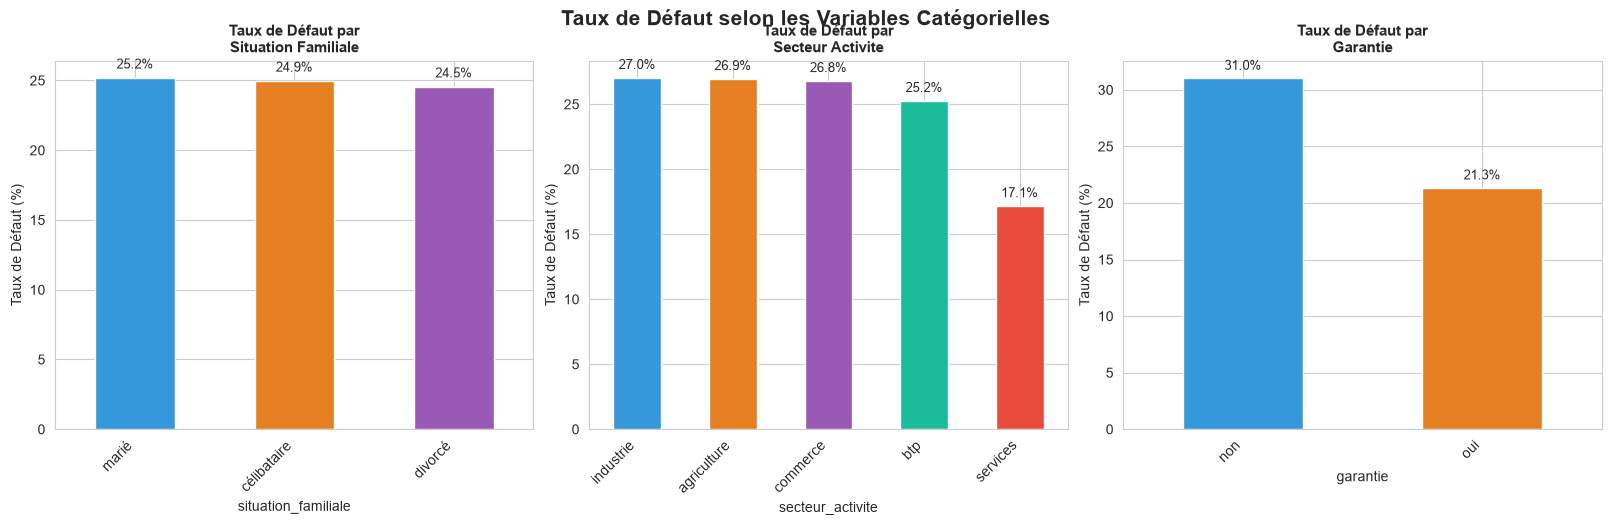

In [10]:

# 4.3.2  Taux de défaut par variables catégorielles


# Variables catégorielles à analyser
vars_cat = ['situation_familiale', 'secteur_activite', 'garantie']

# Créer une grille de sous-graphiques (1 ligne × 3 colonnes)
fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)

# Couleurs pour les barres
palette_cat = ['#3498db', '#e67e22', '#9b59b6', '#1abc9c', '#e74c3c']

# Tracer le taux de défaut pour chaque variable catégorielle
for i, var in enumerate(vars_cat):
    # Calculer le taux de défaut par catégorie
    taux = df.groupby(var)['defaut'].mean() * 100
    # Trier les catégories par taux de défaut décroissant
    taux = taux.sort_values(ascending=False)
    # Tracer un diagramme en barres
    taux.plot(kind='bar', ax=axes[i], color=palette_cat[:len(taux)],
              edgecolor='white', linewidth=1)
    # Titre
    axes[i].set_title(f'Taux de Défaut par\n{var.replace("_", " ").title()}',
                      fontsize=11, fontweight='bold')
    # Label de l'axe y
    axes[i].set_ylabel('Taux de Défaut (%)', fontsize=10)
    # Rotation des labels x
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right')
    # Ajouter la valeur au‑dessus de chaque barre
    for j, v in enumerate(taux.values):
        axes[i].text(j, v + 0.5, f'{v:.1f}%', ha='center', va='bottom', fontsize=9)

# Titre principal
fig.suptitle('Taux de Défaut selon les Variables Catégorielles', fontsize=15, fontweight='bold', y=1.02)


# Afficher
plt.show()

### Observations

- **Garantie** : Les emprunteurs **sans garantie** ont un taux de défaut nettement plus élevé , la garantie est un facteur protecteur.
- **Situation familiale** : Des différences modérées sont observées.
- **Secteur d'activité** : Certains secteurs (agriculture, BTP) peuvent présenter des taux de défaut plus élevés en raison de la volatilité des revenus.

*Note : Dans ce jeu de données synthétique, les différences entre secteurs reflètent uniquement le hasard, car le secteur n'a pas été utilisé pour générer la variable cible.*

### 4.4 Matrice de Corrélation

La matrice de corrélation permet de visualiser les **relations linéaires** entre les variables numériques. Des valeurs proches de +1 ou −1 indiquent une forte corrélation, tandis que des valeurs proches de 0 indiquent l'absence de corrélation linéaire.

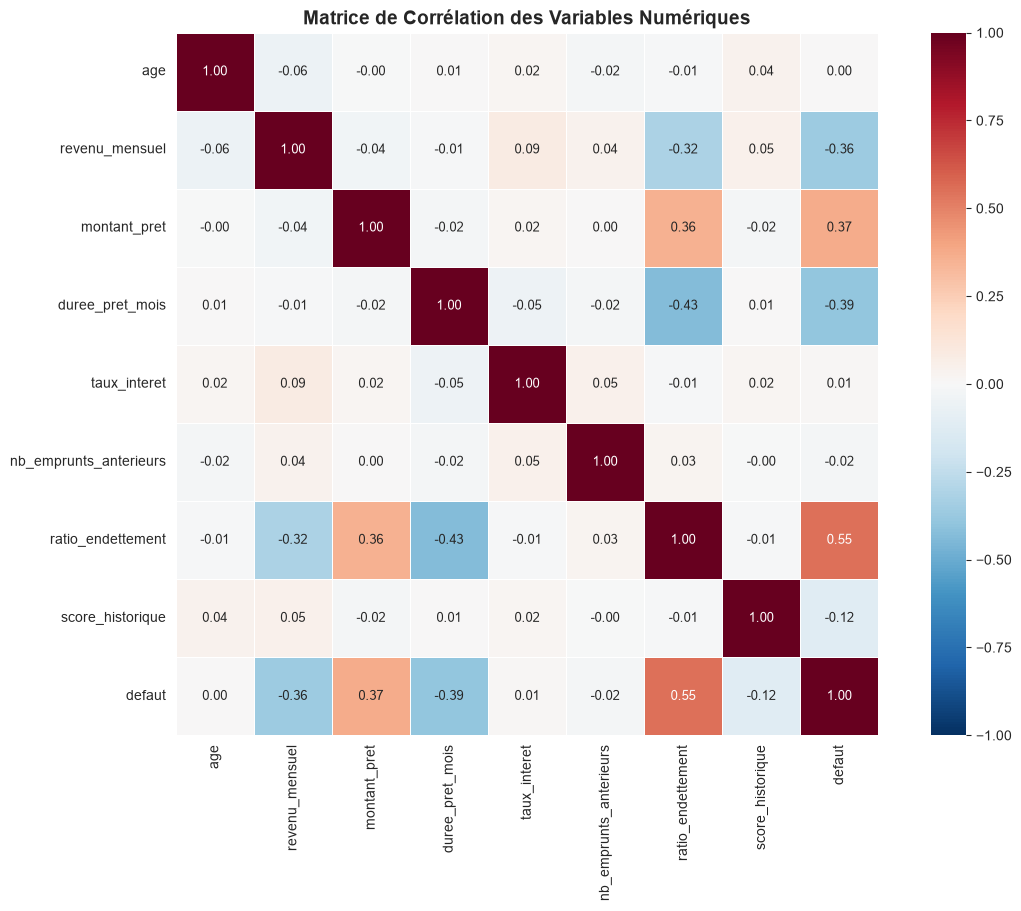

In [11]:

# 4.4  Matrice de corrélation des variables numériques
# Sélectionner uniquement les colonnes numériques
colonnes_num = df.select_dtypes(include=[np.number]).columns.tolist()

# Calculer la matrice de corrélation de Pearson
matrice_corr = df[colonnes_num].corr()

# Créer la figure avec un layout contraint
fig, ax = plt.subplots(figsize=(12, 9), constrained_layout=True)

# Tracer la heatmap de la matrice de corrélation
sns.heatmap(matrice_corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax,
            vmin=-1, vmax=1,  # bornes de la palette de couleurs
            annot_kws={'fontsize': 9})  # taille des annotations

# Titre
ax.set_title('Matrice de Corrélation des Variables Numériques', fontsize=14, fontweight='bold')


# Afficher
plt.show()

### Observations

- La variable la plus corrélée avec le défaut est le **ratio d'endettement** (corrélation positive) et le **score historique** (corrélation négative).
- Aucune **multicolinéarité forte** n'est observée entre les variables explicatives (toutes les corrélations inter‑variables sont < 0.5),
ce qui est favorable pour la régression logistique.
Le montant du prêt et la durée ne sont pas corrélés (r ≈ 0.01), car ces variables sont indépendantes dans notre jeu de données synthétique.

## 5. Prétraitement des Données

Avant d'entraîner les modèles, nous devons préparer les données en effectuant les étapes suivantes :

1. **Vérification des valeurs manquantes**
2. **Encodage des variables catégorielles** (transformer le texte en nombres)
3. **Division** en ensembles d'entraînement (80%) et de test (20%)
4. **Mise à l'échelle** (StandardScaler sur les colonnes numériques, fit sur train uniquement)

### 5.1 Vérification des valeurs manquantes

In [12]:

# 5.1  Vérification des valeurs manquantes

# Compter les valeurs manquantes par colonne
valeurs_manquantes = df.isnull().sum()  # isnull() -> booléen, sum() -> nombre de True

# Calculer le pourcentage de valeurs manquantes
pct_manquantes = (df.isnull().sum() / len(df) * 100).round(2)

# Créer un DataFrame récapitulatif
resume_manquantes = pd.DataFrame({
    'Valeurs manquantes': valeurs_manquantes,
    'Pourcentage (%)': pct_manquantes
})

# Afficher le résumé
print('Vérification des valeurs manquantes :')
print(resume_manquantes)

# Vérifier s'il y a des valeurs manquantes
if valeurs_manquantes.sum() == 0:
    print('\n Aucune valeur manquante détectée.')
else:
    print(f'\n  {valeurs_manquantes.sum()} valeurs manquantes détectées - traitement nécessaire.')

Vérification des valeurs manquantes :
                        Valeurs manquantes  Pourcentage (%)
age                                      0              0.0
revenu_mensuel                           0              0.0
montant_pret                             0              0.0
duree_pret_mois                          0              0.0
taux_interet                             0              0.0
nb_emprunts_anterieurs                   0              0.0
ratio_endettement                        0              0.0
score_historique                         0              0.0
situation_familiale                      0              0.0
secteur_activite                         0              0.0
garantie                                 0              0.0
defaut                                   0              0.0

 Aucune valeur manquante détectée.


Notre jeu de données synthétique est **complet** , il n'y a pas de valeurs manquantes. Dans un cas réel, il faudrait envisager l'imputation (remplacement par la moyenne, la médiane, ou autre).

### 5.2 Encodage des Variables Catégorielles

In [13]:

# 5.2  Encodage des variables catégorielles avec pd.get_dummies

# Séparer les variables explicatives (X) de la variable cible (y)
X = df.drop('defaut', axis=1)  # toutes les colonnes sauf 'defaut'
y = df['defaut']                # uniquement la colonne cible

# Appliquer le one-hot encoding aux variables catégorielles
# drop_first=True supprime la première catégorie pour éviter la multicolinéarité
X_encoded = pd.get_dummies(X, drop_first=True)

# Afficher les dimensions avant et après encodage
print(f'Avant encodage : {X.shape}')
print(f'Après encodage : {X_encoded.shape}')

# Afficher les 3 premières lignes du DataFrame encodé
X_encoded.head(3)

Avant encodage : (1000, 11)
Après encodage : (1000, 15)


,age,revenu_mensuel,montant_pret,duree_pret_mois,taux_interet,nb_emprunts_anterieurs,ratio_endettement,score_historique,situation_familiale_divorcé,situation_familiale_marié,secteur_activite_btp,secteur_activite_commerce,secteur_activite_industrie,secteur_activite_services,garantie_oui
0,60,447234,23789643,111,13.11,0,0.4792,556,False,True,False,False,False,False,True
1,50,61302,36958065,94,9.59,3,6.4137,525,False,True,False,False,False,False,True
2,36,379650,22989029,82,5.63,1,0.7385,449,False,True,False,False,False,False,True


L'encodage **one‑hot** transforme chaque catégorie en une colonne binaire (0/1). Par exemple, la variable `secteur_activite` avec 5 catégories génère 4 colonnes (la 1ère est supprimée via `drop_first=True` pour éviter la **colinéarité parfaite** dans les modèles linéaires).

### 5.3 Division Train/Test et Mise à l'Échelle

In [14]:

# 5.3  Division Train/Test + Standardisation (sans fuite de données)

# Étape 1 : Diviser AVANT toute mise à l'échelle pour éviter la fuite de données
# Le scaler ne doit jamais voir les données de test lors du fit()
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.20,       # 20% des données pour le test
    stratify=y,           # respecter la distribution de la variable cible
    random_state=42       # graine aléatoire pour la reproductibilité
)

# Étape 2 : Standardiser UNIQUEMENT les colonnes numériques (pas les dummies)
scaler = StandardScaler()
num_cols = X_train.select_dtypes(include=[np.number]).columns

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

# Afficher les dimensions et le taux de défaut
print(f'Ensemble d\'entraînement : {X_train_scaled.shape[0]} observations ({X_train_scaled.shape[1]} variables)')
print(f'Ensemble de test       : {X_test_scaled.shape[0]} observations ({X_test_scaled.shape[1]} variables)')
print(f'\nTaux de défaut (train) : {y_train.mean():.1%}')
print(f'Taux de défaut (test)  : {y_test.mean():.1%}')

# Afficher les 3 premières lignes après mise à l'échelle
X_train_scaled.head(3)

Ensemble d'entraînement : 800 observations (15 variables)
Ensemble de test       : 200 observations (15 variables)

Taux de défaut (train) : 25.0%
Taux de défaut (test)  : 25.0%


,age,revenu_mensuel,montant_pret,duree_pret_mois,taux_interet,nb_emprunts_anterieurs,ratio_endettement,score_historique,situation_familiale_divorcé,situation_familiale_marié,secteur_activite_btp,secteur_activite_commerce,secteur_activite_industrie,secteur_activite_services,garantie_oui
780,-1.433177,-0.612497,-0.422558,0.865653,0.814743,1.445716,-0.390824,1.708960,False,False,False,False,False,True,False
515,-0.345450,1.664783,0.933661,-0.548788,1.485202,-1.501717,-0.278799,2.439617,False,True,False,True,False,False,False
172,1.441529,-0.693157,-0.129032,0.404423,-0.698913,-1.501717,-0.289878,-2.604915,False,False,False,False,False,False,False


La **standardisation** (StandardScaler) est appliquée **après** la division train/test et **uniquement sur les colonnes numériques**. Les variables one-hot encodées (0/1) ne sont pas mises à l'échelle.

Le scaler est **fit uniquement sur l'ensemble d'entraînement**, puis utilisé pour transformer l'ensemble de test. Cela évite la **fuite de données** (data leakage) : les statistiques du test ne contaminent pas l'entraînement.

C'est essentiel pour la **régression logistique**, qui est sensible aux échelles différentes. Pour le Random Forest, ce n'est pas strictement nécessaire mais ne nuit pas.

### 5.4 Vérification de la Division

In [15]:

# 5.4  Vérification de la division Train/Test

# La division a été effectuée dans la cellule précédente (5.3)
# avec standardisation correcte (fit sur train uniquement)

# Vérifier que les variables one-hot n'ont pas été mises à l'échelle
dummy_cols = [c for c in X_train_scaled.columns if c not in num_cols]
print(f'Colonnes dummy (non mises à l\'échelle) : {dummy_cols}')
print(f'Valeurs uniques dans les dummies : {sorted(X_train_scaled[dummy_cols].iloc[:, 0].unique())}')
print(f'\nColonnes numériques mises à l\'échelle : {list(num_cols)}')

Colonnes dummy (non mises à l'échelle) : ['situation_familiale_divorcé', 'situation_familiale_marié', 'secteur_activite_btp', 'secteur_activite_commerce', 'secteur_activite_industrie', 'secteur_activite_services', 'garantie_oui']
Valeurs uniques dans les dummies : [np.False_, np.True_]

Colonnes numériques mises à l'échelle : ['age', 'revenu_mensuel', 'montant_pret', 'duree_pret_mois', 'taux_interet', 'nb_emprunts_anterieurs', 'ratio_endettement', 'score_historique']


La division train/test est effectuée **avant** la standardisation pour éviter la fuite de données. Le paramètre `stratify=y` garantit que la **proportion de défauts est identique** dans les deux ensembles. Les variables one-hot encodées (0/1) sont conservées telles quelles , seul le sous-ensemble des colonnes numériques originales est standardisé.

## 6. Modélisation

Nous entraînons deux modèles de classification et les comparons :

1. **Régression Logistique** : modèle linéaire interprétable
2. **Random Forest** : modèle non‑linéaire basé sur des arbres de décision

Pour chaque modèle, nous évaluons :
- La **matrice de confusion** (vrais/faux positifs et négatifs)
- Le **rapport de classification** (précision, rappel, F1)
- La **courbe ROC** et l'**AUC** (capacité de discrimination)

### 6.1 Régression Logistique

La **régression logistique** est un modèle de classification linéaire qui estime la probabilité qu'un événement se produise (ici, le défaut). Elle est particulièrement appréciée pour son **interprétabilité** : les coefficients du modèle indiquent l'impact de chaque variable sur la probabilité de défaut.

In [16]:

# 6.1  Régression Logistique


# Initialiser le modèle de régression logistique
# max_iter=1000 : nombre maximum d'itérations pour la convergence
# random_state=42 : reproductibilité
model_lr = LogisticRegression(max_iter=1000, random_state=42)

# Entraîner le modèle sur l'ensemble d'entraînement
model_lr.fit(X_train_scaled, y_train)

# Prédire les classes sur l'ensemble de test
y_pred_lr = model_lr.predict(X_test_scaled)

# Prédire les probabilités (pour la courbe ROC)
# predict_proba retourne [P(classe 0), P(classe 1)] ; on prend la colonne 1
y_prob_lr = model_lr.predict_proba(X_test_scaled)[:, 1]

# Afficher un message de confirmation
print(' Modèle de régression logistique entraîné.')

 Modèle de régression logistique entraîné.


#### Matrice de Confusion

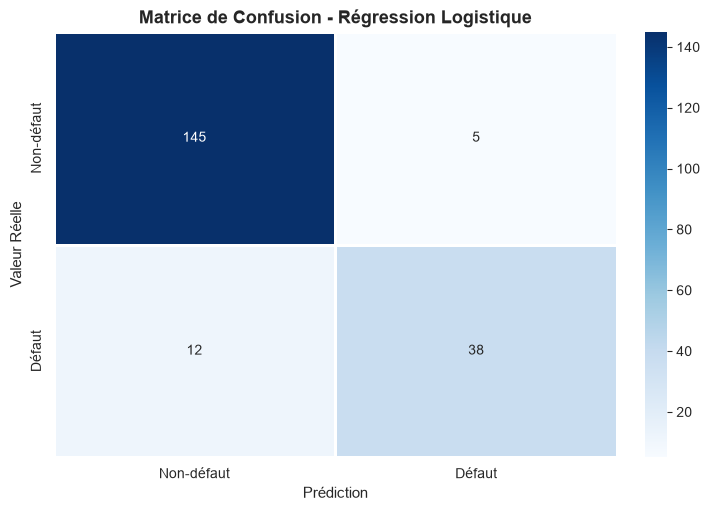

Vrais Négatifs (VN) : 145 - Prédit non-défaut, réel non-défaut
Faux Positifs (FP)  : 5 - Prédit défaut, réel non-défaut
Faux Négatifs (FN)  : 12 - Prédit non-défaut, réel défaut
Vrais Positifs (VP) : 38 - Prédit défaut, réel défaut


In [17]:

# Matrice de confusion — Régression Logistique


# Calculer la matrice de confusion
cm_lr = confusion_matrix(y_test, y_pred_lr)

# Créer la figure
fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)

# Tracer la heatmap de la matrice de confusion
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Non-défaut', 'Défaut'],
            yticklabels=['Non-défaut', 'Défaut'],
            linewidths=1, linecolor='white')

# Titres et labels
ax.set_title('Matrice de Confusion - Régression Logistique', fontsize=13, fontweight='bold')
ax.set_ylabel('Valeur Réelle', fontsize=11)
ax.set_xlabel('Prédiction', fontsize=11)

# Afficher
plt.show()

# Afficher les valeurs de la matrice
vn, fp, fn, vp = cm_lr.ravel()
print(f'Vrais Négatifs (VN) : {vn} - Prédit non-défaut, réel non-défaut')
print(f'Faux Positifs (FP)  : {fp} - Prédit défaut, réel non-défaut')
print(f'Faux Négatifs (FN)  : {fn} - Prédit non-défaut, réel défaut')
print(f'Vrais Positifs (VP) : {vp} - Prédit défaut, réel défaut')

La matrice de confusion montre :
- **Vrais Négatifs (VN)** : bons clients correctement identifiés
- **Vrais Positifs (VP)** : défaillants correctement identifiés
- **Faux Positifs (FP)** : bons clients incorrectement classés comme défaillants
- **Faux Négatifs (FN)** : défaillants manqués , **coûteux pour la banque**

#### Rapport de Classification

In [18]:

# Rapport de classification - Régression Logistique


# Générer le rapport de classification
rapport_lr = classification_report(y_test, y_pred_lr, target_names=['Non-défaut (0)', 'Défaut (1)'])

# Afficher le rapport
print('Rapport de Classification - Régression Logistique :')
print(rapport_lr)

Rapport de Classification - Régression Logistique :
                precision    recall  f1-score   support

Non-défaut (0)       0.92      0.97      0.94       150
    Défaut (1)       0.88      0.76      0.82        50

      accuracy                           0.92       200
     macro avg       0.90      0.86      0.88       200
  weighted avg       0.91      0.92      0.91       200



- **Précision** : parmi les prédits comme défaut, quelle proportion l'est réellement ?
- **Rappel (Recall)** : parmi les vrais défauts, quelle proportion est correctement détectée ?
- **F1‑score** : moyenne harmonique de la précision et du rappel (équilibre)
- **Accuracy** : proportion globale de prédictions correctes

#### Courbe ROC et AUC

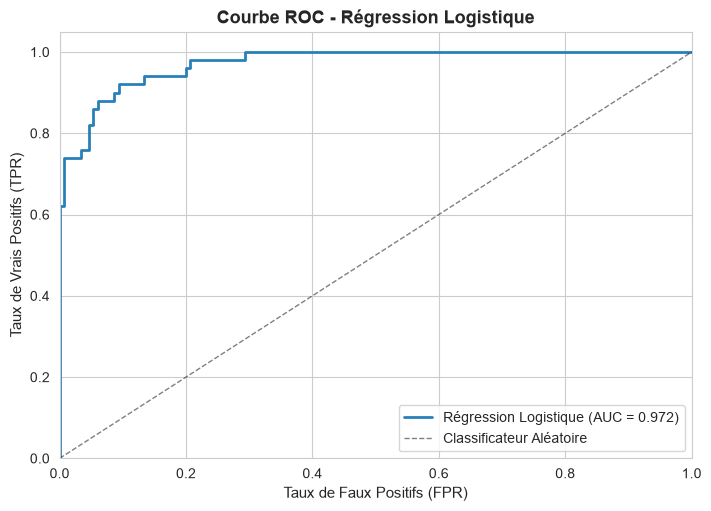

AUC (Régression Logistique) = 0.9721


In [19]:

# Courbe ROC et AUC - Régression Logistique


# Calculer les taux de faux positifs (FPR) et vrais positifs (TPR)
fpr_lr, tpr_lr, seuils_lr = roc_curve(y_test, y_prob_lr)

# Calculer l'aire sous la courbe ROC (AUC)
auc_lr = auc(fpr_lr, tpr_lr)

# Créer la figure
fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)

# Tracer la courbe ROC
ax.plot(fpr_lr, tpr_lr, color='#2980b9', linewidth=2,
        label=f'Régression Logistique (AUC = {auc_lr:.3f})')

# Tracer la diagonale (classificateur aléatoire)
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Classificateur Aléatoire')

# Titres et labels
ax.set_title('Courbe ROC - Régression Logistique', fontsize=13, fontweight='bold')
ax.set_xlabel('Taux de Faux Positifs (FPR)', fontsize=11)
ax.set_ylabel('Taux de Vrais Positifs (TPR)', fontsize=11)
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])


# Afficher
plt.show()

# Afficher l'AUC
print(f'AUC (Régression Logistique) = {auc_lr:.4f}')

La **courbe ROC** illustre le compromis entre le taux de vrais positifs et le taux de faux positifs pour différents seuils de classification.

- Un **AUC de 1.0** indique un classificateur parfait
- Un **AUC de 0.5** indique un classificateur aléatoire
- Plus l'AUC est **élevé**, meilleur est le modèle

### 6.2 Random Forest (Forêt Aléatoire)

Le **Random Forest** est un modèle d'ensemble qui combine plusieurs arbres de décision. Chaque arbre est entraîné sur un sous‑ensemble aléatoire des données et des variables. La prédiction finale est obtenue par **vote majoritaire**. Ce modèle est souvent plus performant que la régression logistique pour les relations non‑linéaires.

In [20]:

# 6.2 - Random Forest


# Initialiser le modèle Random Forest
# n_estimators=100 : nombre d'arbres dans la forêt
# max_depth=10 : profondeur maximale de chaque arbre (pour éviter le surapprentissage)
# random_state=42 : reproductibilité
model_rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)

# Entraîner le modèle sur l'ensemble d'entraînement
model_rf.fit(X_train_scaled, y_train)

# Prédire les classes sur l'ensemble de test
y_pred_rf = model_rf.predict(X_test_scaled)

# Prédire les probabilités (pour la courbe ROC)
y_prob_rf = model_rf.predict_proba(X_test_scaled)[:, 1]

# Afficher un message de confirmation
print(' Modèle Random Forest entraîné.')

 Modèle Random Forest entraîné.


#### Importance des Variables

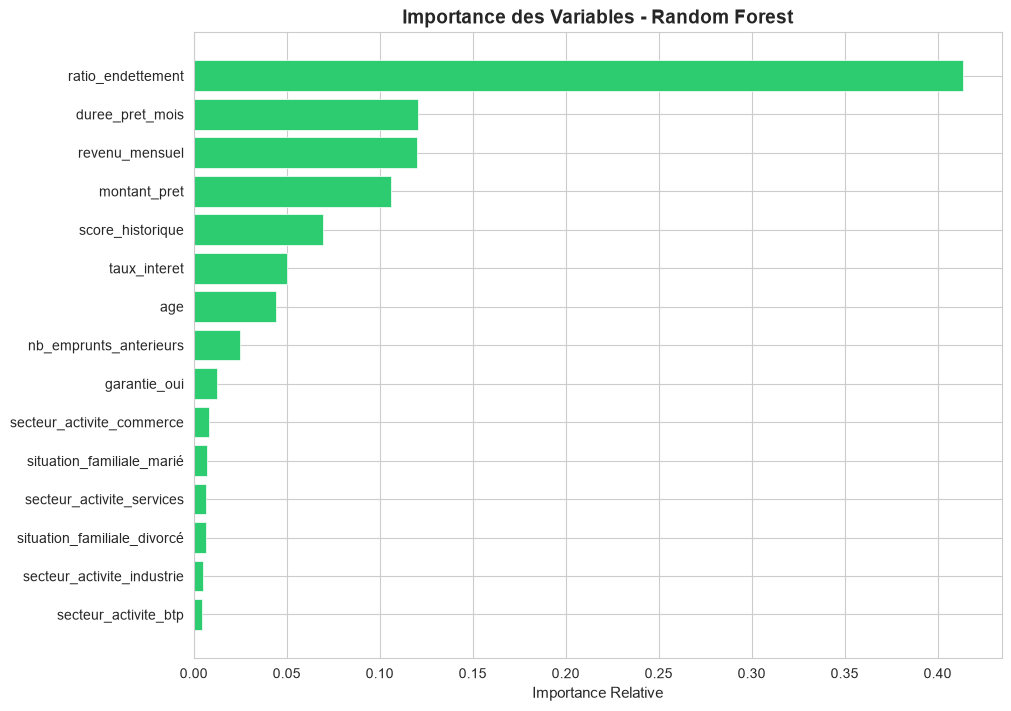

Top 5 des variables les plus importantes :
         Variable  Importance
ratio_endettement    0.413751
  duree_pret_mois    0.120745
   revenu_mensuel    0.119991
     montant_pret    0.106302
 score_historique    0.069567


In [21]:

# Importance des variables - Random Forest


# Extraire l'importance de chaque variable (mesurée par la réduction d'impureté)
importances = model_rf.feature_importances_

# Créer un DataFrame trié par importance décroissante
df_importance = pd.DataFrame({
    'Variable': X_train.columns,
    'Importance': importances
}).sort_values('Importance', ascending=True)  # tri ascendant pour le graphique horizontal

# Créer la figure
fig, ax = plt.subplots(figsize=(10, 7), constrained_layout=True)

# Tracer un diagramme en barres horizontales
ax.barh(df_importance['Variable'], df_importance['Importance'],
        color='#2ecc71', edgecolor='white', linewidth=0.5)

# Titres et labels
ax.set_title('Importance des Variables - Random Forest', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Relative', fontsize=11)


# Afficher
plt.show()

# Afficher le top 5 des variables les plus importantes
print('Top 5 des variables les plus importantes :')
print(df_importance.sort_values('Importance', ascending=False).head(5).to_string(index=False))

L'importance des variables mesure **la contribution de chaque variable** à la qualité des prédictions du Random Forest. Les variables en tête sont celles qui permettent le mieux de distinguer les défaillants des bons payeurs.

#### Matrice de Confusion

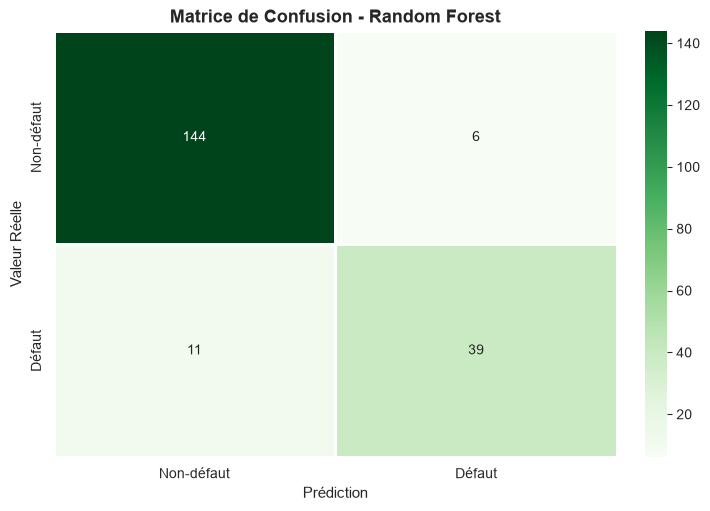

Vrais Négatifs (VN) : 144
Faux Positifs (FP)  : 6
Faux Négatifs (FN)  : 11
Vrais Positifs (VP) : 39


In [22]:

# Matrice de confusion - Random Forest


# Calculer la matrice de confusion
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Créer la figure
fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)

# Tracer la heatmap
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=ax,
            xticklabels=['Non-défaut', 'Défaut'],
            yticklabels=['Non-défaut', 'Défaut'],
            linewidths=1, linecolor='white')

# Titres et labels
ax.set_title('Matrice de Confusion - Random Forest', fontsize=13, fontweight='bold')
ax.set_ylabel('Valeur Réelle', fontsize=11)
ax.set_xlabel('Prédiction', fontsize=11)


# Afficher
plt.show()

# Afficher les valeurs
vn, fp, fn, vp = cm_rf.ravel()
print(f'Vrais Négatifs (VN) : {vn}')
print(f'Faux Positifs (FP)  : {fp}')
print(f'Faux Négatifs (FN)  : {fn}')
print(f'Vrais Positifs (VP) : {vp}')

#### Rapport de Classification

In [23]:

# Rapport de classification - Random Forest

# Générer le rapport
rapport_rf = classification_report(y_test, y_pred_rf, target_names=['Non-défaut (0)', 'Défaut (1)'])

# Afficher
print('Rapport de Classification - Random Forest :')
print(rapport_rf)

Rapport de Classification - Random Forest :
                precision    recall  f1-score   support

Non-défaut (0)       0.93      0.96      0.94       150
    Défaut (1)       0.87      0.78      0.82        50

      accuracy                           0.92       200
     macro avg       0.90      0.87      0.88       200
  weighted avg       0.91      0.92      0.91       200



#### Courbe ROC et AUC

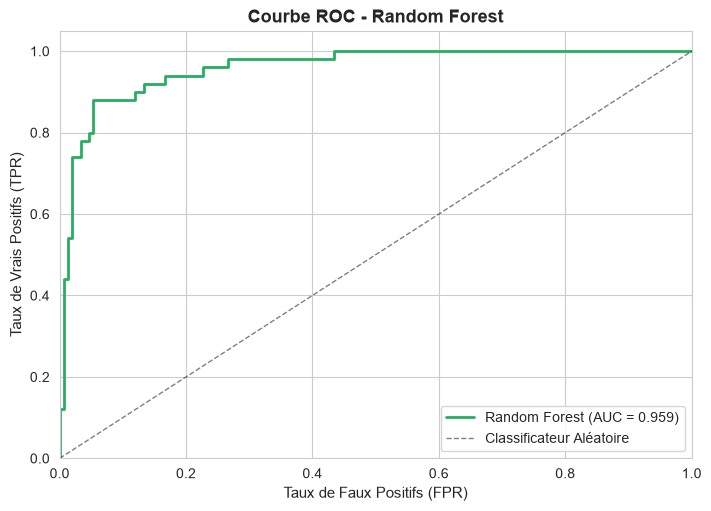

AUC (Random Forest) = 0.9591


In [24]:

# Courbe ROC et AUC - Random Forest


# Calculer FPR et TPR
fpr_rf, tpr_rf, seuils_rf = roc_curve(y_test, y_prob_rf)

# Calculer l'AUC
auc_rf = auc(fpr_rf, tpr_rf)

# Créer la figure
fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)

# Tracer la courbe ROC
ax.plot(fpr_rf, tpr_rf, color='#27ae60', linewidth=2,
        label=f'Random Forest (AUC = {auc_rf:.3f})')

# Diagonale aléatoire
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Classificateur Aléatoire')

# Titres et labels
ax.set_title('Courbe ROC - Random Forest', fontsize=13, fontweight='bold')
ax.set_xlabel('Taux de Faux Positifs (FPR)', fontsize=11)
ax.set_ylabel('Taux de Vrais Positifs (TPR)', fontsize=11)
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])


# Afficher
plt.show()

# Afficher l'AUC
print(f'AUC (Random Forest) = {auc_rf:.4f}')

### 6.3 Comparaison des Modèles

Nous comparons maintenant les performances des deux modèles côte à côte.

#### Tableau Comparatif des Métriques

In [25]:

# 6.3 - Comparaison des performances des deux modèles


# Créer un dictionnaire récapitulatif des métriques
comparaison = {
    'Modèle': ['Régression Logistique', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),       # précision globale RL
        accuracy_score(y_test, y_pred_rf)        # précision globale RF
    ],
    'Précision': [
        precision_score(y_test, y_pred_lr),      # précision RL
        precision_score(y_test, y_pred_rf)       # précision RF
    ],
    'Rappel (Recall)': [
        recall_score(y_test, y_pred_lr),         # rappel RL
        recall_score(y_test, y_pred_rf)          # rappel RF
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_lr),             # F1 RL
        f1_score(y_test, y_pred_rf)              # F1 RF
    ],
    'AUC': [
        auc_lr,                                   # AUC RL
        auc_rf                                    # AUC RF
    ]
}

# Convertir en DataFrame
df_comparaison = pd.DataFrame(comparaison)

# Arrondir les métriques à 4 décimales
df_comparaison = df_comparaison.round(4)

# Afficher le tableau
print('═══ Comparaison des Modèles ═══')
print(df_comparaison.to_string(index=False))

═══ Comparaison des Modèles ═══
               Modèle  Accuracy  Précision  Rappel (Recall)  F1-Score    AUC
Régression Logistique     0.915     0.8837             0.76    0.8172 0.9721
        Random Forest     0.915     0.8667             0.78    0.8211 0.9591


#### Superposition des Courbes ROC

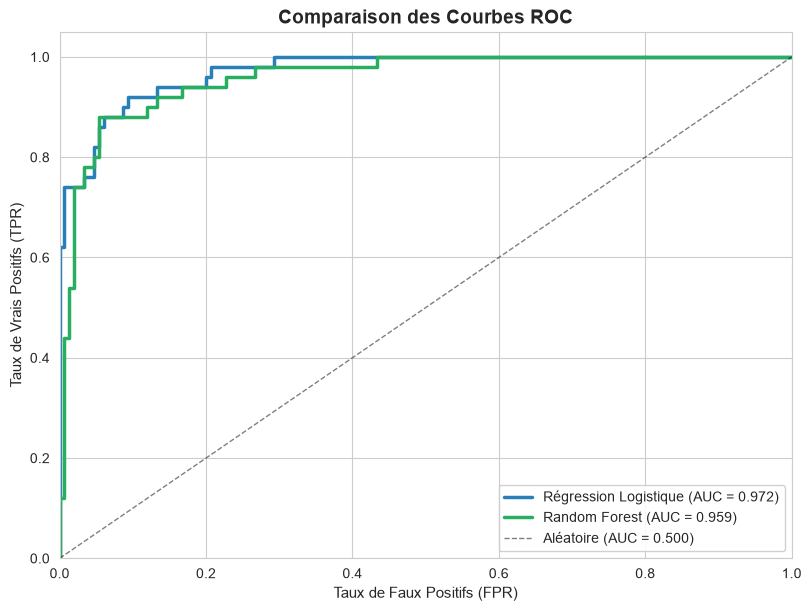

In [26]:

# Comparaison des courbes ROC (superposées)


# Créer la figure
fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)

# Courbe ROC — Régression Logistique
ax.plot(fpr_lr, tpr_lr, color='#2980b9', linewidth=2.5,
        label=f'Régression Logistique (AUC = {auc_lr:.3f})')

# Courbe ROC — Random Forest
ax.plot(fpr_rf, tpr_rf, color='#27ae60', linewidth=2.5,
        label=f'Random Forest (AUC = {auc_rf:.3f})')

# Diagonale aléatoire
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Aléatoire (AUC = 0.500)')

# Titres et labels
ax.set_title('Comparaison des Courbes ROC', fontsize=14, fontweight='bold')
ax.set_xlabel('Taux de Faux Positifs (FPR)', fontsize=11)
ax.set_ylabel('Taux de Vrais Positifs (TPR)', fontsize=11)
ax.legend(loc='lower right', fontsize=10, framealpha=0.9)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])



# Afficher
plt.show()

### Analyse de la Comparaison

Les deux modèles offrent des performances très similaires (Accuracy ≈ 0.915, AUC > 0.95). La **Régression Logistique** obtient une meilleure **AUC (0.972)** et une meilleure **précision (0.884)**, tandis que le **Random Forest** a un léger avantage en **rappel (0.78 vs 0.76)**.

Ces excellentes performances s'expliquent par la nature du jeu de données : les relations entre les variables et la cible sont principalement **linéaires** (le logit est une combinaison linéaire des features), et la correction du signal `ratio_endettement` (via `log1p`) a renforcé la capacité prédictive.

Dans un contexte bancaire, le **rappel du défaut** (recall) est important car il mesure la capacité à détecter les défaillants. Ici les deux modèles sont très proches. La **Régression Logistique** est recommandée pour sa meilleure AUC et sa supérieure **interprétabilité** — les coefficients du modèle sont directement exploitables par les équipes de risque.

## 7. Interprétation et Recommandations

### 7.1 Facteurs de Risque Identifiés

L'analyse exploratoire et l'importance des variables du Random Forest permettent d'identifier les principaux facteurs de risque de défaut :

1. **Ratio d'endettement élevé** : principal indicateur de risque. Un emprunteur dont la mensualité représente une part trop importante de ses revenus est plus susceptible de faire défaut.

2. **Score d'historique de crédit bas** : un mauvais historique de remboursement est un prédicteur fort du défaut futur.

3. **Absence de garantie** : les emprunteurs sans garantie ont un taux de défaut significativement plus élevé.

4. **Montant du prêt élevé** et **faible revenu** : la combinaison d'un prêt important avec un revenu modeste augmente le risque.

5. **Secteur d'activité** : certains secteurs (agriculture, BTP) sont plus sensibles aux cycles économiques et aux aléas climatiques.

### 7.2 Recommandations pour la BOAD

Sur la base des résultats de ce projet, voici des recommandations pour la gestion du risque de crédit à la BOAD :

1. **Adopter un modèle de scoring** intégré au processus de décision de crédit. Même un modèle simple comme la régression logistique offre une amélioration significative par rapport à une décision purement subjective.

2. **Surveiller le ratio d'endettement** de chaque emprunteur et fixer un seuil maximum (par exemple, 40% du revenu mensuel).

3. **Exiger des garanties** pour les prêts à risque élevé, en particulier dans les secteurs volatils.

4. **Développer une base de données d'historique de crédit** régionale partagée entre les pays UEMOA pour améliorer les scores.

5. **Mettre en place un suivi post‑octroi** des prêts identifiés comme risqués, avec des alertes précoces.

6. **Utiliser des techniques de Machine Learning avancées** (Gradient Boosting, réseaux de neurones) une fois les données réelles disponibles, pour capturer des relations non‑linéaires plus complexes.

### 7.3 Limites de l'Étude

Ce projet présente plusieurs limites importantes :

1. **Données synthétiques** : le jeu de données est simulé et ne reflète pas parfaitement la réalité des portefeuilles de la BOAD.

2. **Variables simplifiées** : de nombreux facteurs réels (endettement extérieur, garanties reçues, conjoncture économique) ne sont pas inclus.

3. **Période temporelle** : un modèle de scoring doit être ré‑entraîné régulièrement pour s'adapter aux évolutions macroéconomiques.

4. **Biais potentiels** : les données synthétiques peuvent introduire des biais non intentionnels dans les relations entre variables.

5. **Pas de validation croisée** : une validation k‑folds serait nécessaire pour une évaluation plus robuste des performances.

## 8. Conclusion

Ce projet a démontré l'application complète du processus de **Data Science** à la problématique du **scoring crédit** dans le contexte de la BOAD :

<table style="width:100%; border-collapse: collapse; text-align: center; font-family: sans-serif;">
  <thead>
    <tr style="background-color: #f2f2f2; border-bottom: 2px solid #ddd;">
      <th>ID</th>
      <th>Étape</th>
      <th>Description</th>
    </tr>
  </thead>
  <tbody>
    <tr style="border-bottom: 1px solid #ddd;">
      <td>1</td>
      <td><strong>Données</strong></td>
      <td>Création d'un jeu de données synthétique réaliste (1 000 demandes)</td>
    </tr>
    <tr style="border-bottom: 1px solid #ddd;">
      <td>2</td>
      <td><strong>EDA</strong></td>
      <td>Analyse exploratoire approfondie (distributions, corrélations, analyses bivariées)</td>
    </tr>
    <tr style="border-bottom: 1px solid #ddd;">
      <td>3</td>
      <td><strong>Prétraitement</strong></td>
      <td>Encodage, standardisation, division train/test</td>
    </tr>
    <tr style="border-bottom: 1px solid #ddd;">
      <td>4</td>
      <td><strong>Modélisation</strong></td>
      <td>Régression logistique et Random Forest</td>
    </tr>
    <tr style="border-bottom: 1px solid #ddd;">
      <td>5</td>
      <td><strong>Évaluation</strong></td>
      <td>Matrice de confusion, métriques de classification, courbes ROC</td>
    </tr>
    <tr>
      <td>6</td>
      <td><strong>Recommandations</strong></td>
      <td>Propositions concrètes pour la BOAD</td>
    </tr>
  </tbody>
</table>

### Points Clés
<ul>
    <li>Le ratio d'endettement et le score d'historique de crédit sont les prédicteurs les plus puissants du défaut.</li>
    <li>Les modèles de Machine Learning peuvent <b>significativement améliorer</b> la prise de décision crédit par rapport à une approche manuelle.</li>
    <li> Pour une mise en production à la BOAD, il sera essentiel de travailler avec les données réelles du portefeuille bancaire et d'intégrer des données macroéconomiques spécifiques aux pays de l'UEMOA.
</li>
</ul>

### Perspectives

Ce projet constitue une **base solide** qui pourrait être étendue par :
<ul>
    <li>L'ajout de modèles plus avancés (XGBoost, LightGBM)</li>
    <li>L'implémentation d'une validation croisée stratifiée</li>
    <li>La réalisation d'un dashboard interactif pour les analystes de crédit</li>
    <li> L'intégration de données temporelles (séries macroéconomiques)</li>
</ul>


